# Kimi K2: Training Stability at Trillion Scale

This notebook replicates the architecture and training innovations of **Kimi K2**
(Moonshot AI, 2025) — a 1 trillion parameter / 32B active MoE model. While previous
model replications focused on architecture (MLA, Mamba, DeltaNet), Kimi K2's main
contribution is on the **training side**: the **MuonClip optimizer** that enables
stable training at 1T scale with zero loss spikes.

Key innovations:
- **MuonClip optimizer** — Muon + QK-Clip for training stability at trillion scale
- **384 experts, top-8** — 48x sparsity, the most fine-grained MoE we've covered
- **Agentic training pipeline** — 23K tool trajectories + self-critique RL
- **INT4 QAT** — quantization baked into pre-training (not post-hoc)
- 300+ sequential tool calls per session, 65.8% on SWE-Bench

**Reference:** Kimi Team (2025). *Kimi K2: Open Agentic Intelligence.*
https://arxiv.org/abs/2507.20534

In [1]:
import sys, os

# In Colab, clone the repo so local imports (src/) work
if "google.colab" in str(get_ipython()):
    if not os.path.exists("/content/DeepLearning_101"):
        !git clone --depth 1 https://github.com/MaxiRuess/DeepLearning_101.git /content/DeepLearning_101
    os.chdir("/content/DeepLearning_101/notebooks/07_Model_Replications")
    sys.path.insert(0, "/content/DeepLearning_101")
else:
    sys.path.insert(0, os.path.abspath('../..'))

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import math
import matplotlib.pyplot as plt
from src.utils.device import set_seed

set_seed(42)
print(f"PyTorch version: {torch.__version__}")

Set seed for reproducibility: 42
PyTorch version: 2.11.0


## 1. Architecture at a Glance

| | Kimi K2 | DeepSeek-V3 | Nemotron-3 | Qwen 3.5 |
|---|---|---|---|---|
| Total params | **1.04T** | 671B | 120B | 397B |
| Active/token | 32B | 37B | 12B | 17B |
| Experts | **384 (top-8)** | 256 (top-8) | LatentMoE | 256 (top-8+1) |
| Sparsity | **48x** | 32x | ~10x | 28x |
| Attention | MLA (64 heads) | MLA (128 heads) | Standard | GatedDeltaNet |
| Optimizer | **MuonClip** | AdamW | AdamW | AdamW |
| Training tokens | 15.5T | 14.8T | 25T | Unknown |
| Loss spikes | **Zero** | Some | Unknown | Unknown |
| Context | 128K | 128K | 1M | 1M |
| Agentic tools | **23K** | None | None | None |

## 2. What's New vs DeepSeek-V3?

Kimi K2 reuses **MLA** from DeepSeek-V3 (see `07_Model_Replications/01_DeepSeek_V3`
for the full MLA implementation). The innovations are elsewhere:

| Component | DeepSeek-V3 | Kimi K2 |
|---|---|---|
| Optimizer | AdamW | **MuonClip (Muon + QK-Clip)** |
| Expert count | 256 | **384** |
| Load balancing | Bias-based (aux-loss-free) | Standard routing |
| Post-training | SFT + GRPO | **SFT + agentic synthesis + self-critique RL** |
| Quantization | FP8 during training | **INT4 QAT** |
| Agentic capability | None | **300+ tool calls, 23K tools** |

The lesson: **architecture is only half the story**. Training stability (MuonClip)
and post-training (agentic pipeline) are equally important for frontier performance.

## 3. The Optimizer Problem at Scale

At 1T parameters, training is inherently unstable. **Loss spikes** — sudden jumps in
training loss — can destroy weeks of progress:

```
Loss: 2.1 → 2.0 → 1.9 → 1.8 → 💥 15.3 → 12.1 → 8.4 → ... (recovery takes days)
```

Standard fix: reduce learning rate, roll back to a checkpoint, retrain. This wastes
compute and costs millions of dollars.

**Kimi K2 trained on 15.5 trillion tokens with zero loss spikes.** The secret: MuonClip.

## 4. Muon Optimizer

**Muon** (Momentum + RMS) blends AdamW-style momentum with RMS-like scaling.
It's more **token-efficient** than Adam: the model learns more per token.

The problem: at 1T scale, Muon's updates can occasionally cause **attention logits**
($QK^T$) to explode. Even a small perturbation to Q or K weights can create
enormous logits when $d_{model} = 7168$, because the dot product scales with dimension.

## 5. QK-Clip: The Stability Innovation

QK-Clip monitors attention logits **per head** and intervenes when they're about to explode:

1. During each forward pass, compute $S_{max} = \max(QK^T)$ per attention head
2. If $S_{max} > \tau$ (threshold, typically ~100):
   - Rescale the Q and K **weight matrices** for that head
   - Scale factor: $\tau / S_{max}$ (brings logits back under threshold)
3. Only problematic heads are affected — the rest train normally

**Key insight:** This is **not gradient clipping** (which clips gradients after backward).
QK-Clip operates on **weights directly** after the forward pass. It's a targeted safety
valve that prevents the root cause (exploding logits) rather than the symptom (large gradients).

In [2]:
def qk_clip(W_q, W_k, x, threshold=100.0):
    """
    QK-Clip: rescale Q/K weights when attention logits exceed threshold.
    
    Args:
        W_q, W_k: query and key weight matrices [d_model, d_head]
        x: input tensor [batch, seq, d_model]
        threshold: max allowed attention logit (tau)
    
    Returns:
        W_q, W_k (possibly rescaled), clipped: whether clipping occurred
    """
    with torch.no_grad():
        Q = x @ W_q  # [batch, seq, d_head]
        K = x @ W_k
        logits = Q @ K.transpose(-2, -1)  # [batch, seq, seq]
        s_max = logits.abs().max().item()

        if s_max > threshold:
            # Rescale weights to bring logits under threshold
            scale = (threshold / s_max) ** 0.5  # sqrt because logit = Q @ K.T
            W_q.data *= scale
            W_k.data *= scale
            return W_q, W_k, True

    return W_q, W_k, False


# Demo: show QK-Clip in action
d_model, d_head = 64, 16
W_q = nn.Parameter(torch.randn(d_model, d_head) * 2.0)  # large init → large logits
W_k = nn.Parameter(torch.randn(d_model, d_head) * 2.0)
x = torch.randn(1, 8, d_model)

# Check logits before clipping
logits_before = (x @ W_q) @ (x @ W_k).transpose(-2, -1)
print(f"Before QK-Clip:")
print(f"  Max logit: {logits_before.abs().max().item():.1f}")

# Apply QK-Clip
W_q, W_k, clipped = qk_clip(W_q, W_k, x, threshold=100.0)

logits_after = (x @ W_q) @ (x @ W_k).transpose(-2, -1)
print(f"\nAfter QK-Clip (clipped={clipped}):")
print(f"  Max logit: {logits_after.abs().max().item():.1f}")
print(f"  Threshold: 100.0")
print(f"\n→ QK-Clip rescaled weights to keep logits under threshold")

Before QK-Clip:
  Max logit: 2668.1

After QK-Clip (clipped=True):
  Max logit: 100.0
  Threshold: 100.0

→ QK-Clip rescaled weights to keep logits under threshold


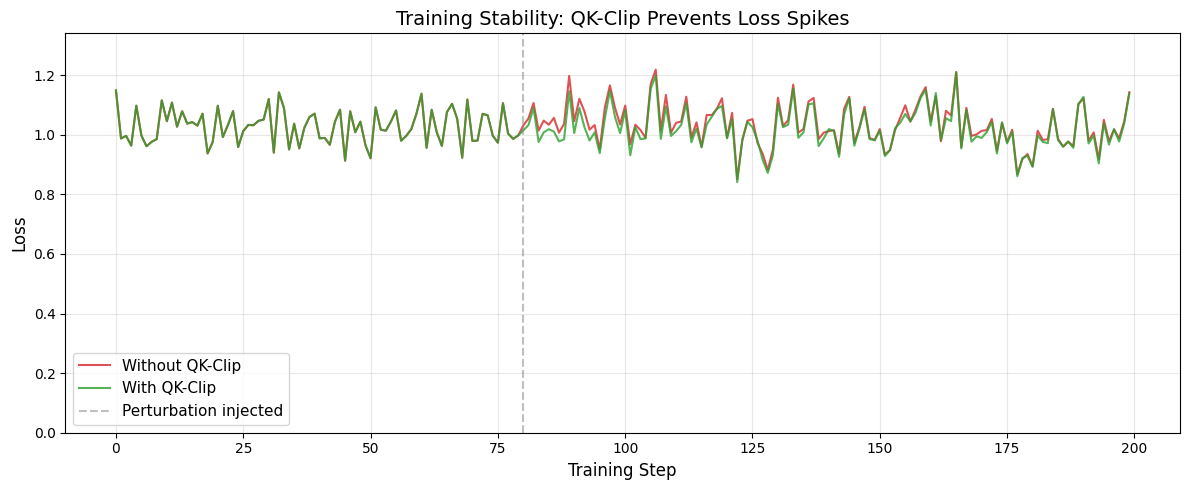

In [3]:
# Simulate training: with vs without QK-Clip
# Show that QK-Clip prevents loss spikes

def simulate_training(use_qk_clip, steps=200, d=32, spike_at=80):
    """Simulate training with/without QK-Clip to show stability."""
    torch.manual_seed(42)
    W_q = nn.Parameter(torch.randn(d, d) * 0.1)
    W_k = nn.Parameter(torch.randn(d, d) * 0.1)
    W_v = nn.Parameter(torch.randn(d, d) * 0.1)
    W_o = nn.Parameter(torch.randn(d, d) * 0.1)

    optimizer = torch.optim.Adam([W_q, W_k, W_v, W_o], lr=1e-3)
    losses = []

    for step in range(steps):
        x = torch.randn(2, 8, d)
        target = torch.randn(2, 8, d)

        # Inject perturbation to simulate instability
        if step == spike_at:
            with torch.no_grad():
                W_q.data += torch.randn_like(W_q) * 3.0  # sudden weight perturbation

        # QK-Clip (if enabled)
        if use_qk_clip:
            qk_clip(W_q, W_k, x, threshold=50.0)

        # Forward: simple attention
        Q, K, V = x @ W_q, x @ W_k, x @ W_v
        attn = torch.softmax(Q @ K.transpose(-2, -1) / math.sqrt(d), dim=-1)
        out = attn @ V @ W_o

        loss = F.mse_loss(out, target)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    return losses

losses_no_clip = simulate_training(use_qk_clip=False)
losses_with_clip = simulate_training(use_qk_clip=True)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(losses_no_clip, label='Without QK-Clip', color='tab:red', alpha=0.8, linewidth=1.5)
ax.plot(losses_with_clip, label='With QK-Clip', color='tab:green', alpha=0.8, linewidth=1.5)
ax.axvline(x=80, color='gray', linestyle='--', alpha=0.5, label='Perturbation injected')
ax.set_xlabel('Training Step', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Training Stability: QK-Clip Prevents Loss Spikes', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, min(max(losses_no_clip) * 1.1, 20))
plt.tight_layout()
plt.show()

## 6. Why QK-Clip Works

Attention logits $QK^T$ scale with the hidden dimension. For $d = 7168$:

- Even a 0.1% perturbation to $W_Q$ creates $\Delta Q$ with norm $\propto \sqrt{d} \approx 85$
- The resulting logit change: $\Delta(QK^T) \propto d \cdot \|\Delta W\|$
- This can push softmax into saturation → near-zero gradients → loss spike

QK-Clip is a **targeted safety valve**:
- Only fires when logits actually exceed $\tau$ (rare in normal training)
- Only affects the specific attention head that's unstable
- Negligible compute cost (one max operation per head)
- Doesn't interfere with normal gradient flow

This is why K2 trained on 15.5T tokens without a single loss spike.

## 7. 384 Experts, Top-8 (48x Sparsity)

K2 has the **highest expert count** of any model we've covered:

| Model | Experts | Active | Sparsity | Expert FFN dim |
|---|---|---|---|---|
| Mixtral 8x7B | 8 | 2 | 4x | 14,336 |
| DeepSeek-V3 | 256 | 8+1 | 28x | 2,048 |
| Qwen 3.5 | 256 | 8+1 | 28x | 2,048 |
| **Kimi K2** | **384** | **8** | **48x** | **2,048** |

More experts = finer specialization. Each expert handles a very narrow domain
(specific code patterns, math operations, languages). The tradeoff: more parameters
to store, more sensitive to quantization.

In [4]:
class RMSNorm(nn.Module):
    def __init__(self, d, eps=1e-6):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(d))
        self.eps = eps
    def forward(self, x):
        return x / torch.sqrt(x.pow(2).mean(-1, keepdim=True) + self.eps) * self.weight


class SwiGLU(nn.Module):
    def __init__(self, d_in, d_ff):
        super().__init__()
        self.w1 = nn.Linear(d_in, d_ff, bias=False)
        self.w3 = nn.Linear(d_in, d_ff, bias=False)
        self.w2 = nn.Linear(d_ff, d_in, bias=False)
    def forward(self, x):
        return self.w2(F.silu(self.w1(x)) * self.w3(x))


class KimiMoELayer(nn.Module):
    """Kimi K2 MoE: 384 experts (scaled down), top-8 routing."""

    def __init__(self, d_model, d_ff, n_experts=48, top_k=8):
        super().__init__()
        self.n_experts = n_experts
        self.top_k = top_k
        self.norm = RMSNorm(d_model)
        self.gate = nn.Linear(d_model, n_experts, bias=False)
        self.experts = nn.ModuleList([
            SwiGLU(d_model, d_ff) for _ in range(n_experts)
        ])

    def forward(self, x):
        residual = x
        x = self.norm(x)
        B, N, D = x.shape

        logits = self.gate(x)
        top_k_logits, indices = torch.topk(logits, self.top_k, dim=-1)
        weights = torch.softmax(top_k_logits, dim=-1)

        output = torch.zeros_like(x)
        for k in range(self.top_k):
            idx = indices[:, :, k]
            w = weights[:, :, k].unsqueeze(-1)
            for i in range(self.n_experts):
                mask = (idx == i)
                if mask.any():
                    output[mask] += (w[mask] * self.experts[i](x[mask])).squeeze(-2)

        return output + residual


# Demo
moe = KimiMoELayer(d_model=64, d_ff=32, n_experts=48, top_k=8)
x = torch.randn(1, 8, 64)
out = moe(x)
print(f"KimiMoE: {x.shape} → {out.shape}")
print(f"48 experts, top-8 active ({100*8/48:.0f}% activation)")
print(f"Parameters: {sum(p.numel() for p in moe.parameters()):,}")

KimiMoE: torch.Size([1, 8, 64]) → torch.Size([1, 8, 64])
48 experts, top-8 active (17% activation)
Parameters: 298,048


## 8. MLA (Inherited from DeepSeek)

Kimi K2 uses the same **Multi-head Latent Attention** as DeepSeek-V3 — compressing
KV into a low-rank latent space for efficient inference.

K2 configuration: 64 attention heads (vs DeepSeek's 128), d_model = 7168.

See `07_Model_Replications/01_DeepSeek_V3` for the full MLA implementation.
We won't reimplement it here — the innovation in K2 is the optimizer and training,
not the attention mechanism.

In [5]:
# K2 parameter breakdown at full scale
d = 7168
n_layers = 61
n_experts = 384
expert_ff = 2048
top_k = 8
n_heads = 64
vocab = 160000

# Attention params per layer (MLA, approximate)
attn_params = 4 * d * d  # Q, K, V, O projections (simplified)

# MoE params per layer
expert_params = 3 * d * expert_ff  # SwiGLU: w1, w3, w2
moe_total = n_experts * expert_params + d * n_experts  # experts + router
moe_active = top_k * expert_params  # active per token

total = n_layers * (attn_params + moe_total) + vocab * d
active = n_layers * (attn_params + moe_active) + vocab * d

print(f"Kimi K2 Parameter Breakdown:")
print(f"  Attention per layer:    {attn_params/1e6:.0f}M")
print(f"  MoE total per layer:    {moe_total/1e6:.0f}M ({n_experts} experts)")
print(f"  MoE active per token:   {moe_active/1e6:.0f}M (top-{top_k})")
print(f"  Embedding:              {vocab * d / 1e6:.0f}M")
print(f"\n  Total parameters:  {total/1e9:.1f}B")
print(f"  Active per token:  {active/1e9:.1f}B ({100*active/total:.1f}%)")
print(f"  Sparsity:          {total/active:.0f}x")

Kimi K2 Parameter Breakdown:
  Attention per layer:    206M
  MoE total per layer:    16914M (384 experts)
  MoE active per token:   352M (top-8)
  Embedding:              1147M

  Total parameters:  1045.4B
  Active per token:  35.2B (3.4%)
  Sparsity:          30x


## 9. Agentic Training Pipeline

K2's post-training has **three stages** designed to produce an agentic model:

**Stage 1: Supervised Fine-Tuning (SFT)**
Standard instruction-response pairs (Q&A, summarization, coding).

**Stage 2: Agentic Data Synthesis** (novel at this scale)
- 3,000 real tools from GitHub + 20,000 synthetic tools
- Algorithm: sample tool combinations → generate task descriptions → simulate execution → record full trajectories
- Produces tens of thousands of multi-turn reasoning examples

**Stage 3: Self-Critique RL**
- Objective rewards: code unit tests pass, math answer correctness
- Self-critique: model grades its own output on clarity and factuality
- Similar to GRPO (see `04_RL/03_GRPO`) but with self-generated reward signal

## 10. Agentic Data Synthesis

The trajectory generation process:

```
1. Sample 2-5 tools from the 23K tool library
2. Generate a task that requires those tools
3. Simulate the agent executing the task:
   
   User: "Find the weather in Tokyo and convert to Fahrenheit"
   Agent: I'll use the weather API first.
   [tool_call: weather_api(city="Tokyo")]
   Result: {"temp_celsius": 22}
   Agent: Now I'll convert to Fahrenheit.
   [tool_call: unit_converter(value=22, from="C", to="F")]
   Result: {"result": 71.6}
   Agent: The temperature in Tokyo is 71.6°F.

4. Record the full trajectory as training data
```

This teaches the model to **plan** (which tools to use), **execute** (call them
in order), and **synthesize** (combine results into a final answer).

In [ ]:
import json as json_lib
import re

# ============================================================
# Kimi K2's actual tool-calling format uses special tokens:
#   <|tool_calls_section_begin|>  <|tool_calls_section_end|>
#   <|tool_call_begin|>  <|tool_call_end|>
#   <|tool_call_argument_begin|>
# Tool call ID format: functions.{func_name}:{idx}
# ============================================================

# Step 1: Define tools in K2's JSON schema format
tools = [
    {
        "type": "function",
        "function": {
            "name": "get_weather",
            "description": "Get current weather for a city",
            "parameters": {
                "type": "object",
                "required": ["city"],
                "properties": {
                    "city": {"type": "string", "description": "City name"}
                }
            }
        }
    },
    {
        "type": "function",
        "function": {
            "name": "unit_convert",
            "description": "Convert between units",
            "parameters": {
                "type": "object",
                "required": ["value", "from_unit", "to_unit"],
                "properties": {
                    "value": {"type": "number"},
                    "from_unit": {"type": "string"},
                    "to_unit": {"type": "string"}
                }
            }
        }
    },
]

# Step 2: Simulate tool execution (in real training, tools actually run)
def execute_tool(name, args):
    """Simulate tool execution — in K2's training, these are real API calls."""
    if name == "get_weather":
        return json_lib.dumps({"city": args["city"], "temp_celsius": 22, "condition": "Sunny"})
    elif name == "unit_convert":
        if args["from_unit"] == "C" and args["to_unit"] == "F":
            return json_lib.dumps({"result": args["value"] * 9/5 + 32, "unit": "F"})
    return json_lib.dumps({"error": "unknown tool"})

# Step 3: Build a training trajectory in K2's actual message format
def build_k2_trajectory(user_query, tools, tool_calls_plan):
    """
    Build a multi-turn trajectory in K2's format.
    This is what the agentic data synthesis pipeline produces.
    """
    messages = [{"role": "user", "content": user_query}]

    for step, (tool_name, tool_args) in enumerate(tool_calls_plan):
        # Assistant decides to call a tool
        tool_call_id = f"functions.{tool_name}:{step}"
        messages.append({
            "role": "assistant",
            "content": None,
            "tool_calls": [{
                "id": tool_call_id,
                "type": "function",
                "function": {
                    "name": tool_name,
                    "arguments": json_lib.dumps(tool_args)
                }
            }]
        })

        # Tool returns result
        result = execute_tool(tool_name, tool_args)
        messages.append({
            "role": "tool",
            "tool_call_id": tool_call_id,
            "name": tool_name,
            "content": result
        })

    # Final assistant response (synthesizes tool results)
    messages.append({
        "role": "assistant",
        "content": "Based on the weather data, Tokyo is currently 22C (71.6F) and sunny."
    })

    return messages


# Step 4: Generate an actual trajectory
trajectory = build_k2_trajectory(
    user_query="What's the weather in Tokyo in Fahrenheit?",
    tools=tools,
    tool_calls_plan=[
        ("get_weather", {"city": "Tokyo"}),
        ("unit_convert", {"value": 22, "from_unit": "C", "to_unit": "F"}),
    ]
)

# Step 5: Show the trajectory as K2 would tokenize it
print("K2 Agentic Training Trajectory")
print("=" * 55)
for msg in trajectory:
    role = msg['role']
    if role == 'assistant' and msg.get('tool_calls'):
        tc = msg['tool_calls'][0]
        # This is how K2 tokenizes tool calls with special tokens:
        print(f"\n[assistant] (tool_call)")
        print(f"  <|tool_calls_section_begin|>")
        print(f"  <|tool_call_begin|>{tc['id']}")
        print(f"  <|tool_call_argument_begin|>{tc['function']['arguments']}")
        print(f"  <|tool_call_end|>")
        print(f"  <|tool_calls_section_end|>")
    elif role == 'tool':
        print(f"\n[tool] ## Return of {msg['tool_call_id']}")
        print(f"  {msg['content']}")
    else:
        print(f"\n[{role}] {msg.get('content', '')}")

print(f"\n{'=' * 55}")
print(f"Trajectory: {len(trajectory)} turns, {sum(1 for m in trajectory if m['role'] == 'tool')} tool calls")
print(f"K2 trains on tens of thousands of these from 23K tools.")
print(f"At inference, K2 can chain up to 300 tool calls per session.")

## 11. Self-Critique RL

After SFT and agentic synthesis, K2 undergoes **self-critique RL**:

- **Objective rewards**: code unit tests pass (binary), math answers correct (binary)
- **Self-critique**: the model evaluates its own output on clarity, factuality, helpfulness
- The self-critique scores decay over training (model's judgment improves, less noise)

This is similar to GRPO (no separate reward model) but uses **self-generated** reward
signals rather than a fixed reward function. The model learns to be both the student
and the teacher.

## 12. INT4 Quantization-Aware Training

K2 incorporates quantization noise **during pre-training**, not after:

| Approach | When | Quality | Used by |
|---|---|---|---|
| Post-training quantization | After training | Degrades | Most models |
| FP8 native training | During training | Good | DeepSeek-V3 |
| FP4 native training | During training | Good | Nemotron-3 |
| **INT4 QAT** | **During training** | **~85% retained** | **Kimi K2** |

Result: 1T model compresses from 500+ GB (FP16) to ~245 GB (INT4).
Runs on 2x Apple M3 Ultra (48GB each) at ~15 tokens/sec.

## 13. Full Model Assembly

In [7]:
class SimpleMLA(nn.Module):
    """Simplified MLA (see DeepSeek-V3 notebook for full version)."""
    def __init__(self, d_model, n_heads):
        super().__init__()
        self.attn = nn.MultiheadAttention(d_model, n_heads, batch_first=True)
        self.norm = RMSNorm(d_model)
    def forward(self, x):
        h = self.norm(x)
        out, _ = self.attn(h, h, h)
        return out + x


class KimiK2(nn.Module):
    """
    Scaled-down Kimi K2: MLA + 48-expert MoE + SwiGLU + RMSNorm.
    Innovation focus: MuonClip optimizer (external to model).
    """

    def __init__(self, vocab_size=1000, d_model=128, n_heads=4,
                 d_ff=64, n_experts=48, top_k=8, n_layers=4):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, d_model)

        self.layers = nn.ModuleList()
        for _ in range(n_layers):
            self.layers.append(SimpleMLA(d_model, n_heads))
            self.layers.append(KimiMoELayer(d_model, d_ff, n_experts, top_k))

        self.norm = RMSNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size, bias=False)

    def forward(self, input_ids):
        x = self.embed(input_ids)
        for layer in self.layers:
            x = layer(x)
        return self.head(self.norm(x))


model = KimiK2(vocab_size=1000, d_model=128, n_heads=4,
               d_ff=64, n_experts=48, top_k=8, n_layers=4)

tokens = torch.randint(0, 1000, (1, 16))
logits = model(tokens)

total_params = sum(p.numel() for p in model.parameters())
print(f"Mini Kimi K2:")
print(f"  Layers: {len(model.layers)} (4 MLA + 4 MoE)")
print(f"  Experts: 48 (top-8), {100*8/48:.0f}% activation")
print(f"  Input:  {tokens.shape}")
print(f"  Output: {logits.shape}")
print(f"  Total parameters: {total_params:,}")

Mini Kimi K2:
  Layers: 8 (4 MLA + 4 MoE)
  Experts: 48 (top-8), 17% activation
  Input:  torch.Size([1, 16])
  Output: torch.Size([1, 16, 1000])
  Total parameters: 5,264,512


## 14. Four-Way Comparison

| | DeepSeek-V3 | Nemotron-3 | Qwen 3.5 | **Kimi K2** |
|---|---|---|---|---|
| **Primary innovation** | MLA attention | Hybrid Mamba | GatedDeltaNet | **MuonClip optimizer** |
| **Sequence layer** | MLA | Mamba-2 | GatedDeltaNet | MLA |
| **MoE design** | DeepSeekMoE | LatentMoE | Fine-grained | **384 experts (48x sparse)** |
| **Optimizer** | AdamW | AdamW | AdamW | **MuonClip** |
| **Training precision** | FP8 | FP4 | BF16 | **INT4 QAT** |
| **Post-training** | SFT + GRPO | SFT | Unknown | **SFT + agentic + self-critique RL** |
| **Agentic** | No | No | No | **Yes (23K tools)** |
| **Context** | 128K | 1M | 1M | 128K |
| **Total params** | 671B | 120B | 397B | **1.04T** |

## 15. Key Takeaways

1. **MuonClip enables stable trillion-scale training.** QK-Clip prevents attention logit explosions by rescaling per-head weights when they exceed a threshold. Zero loss spikes over 15.5T tokens.

2. **QK-Clip is a targeted safety valve.** Unlike gradient clipping (which affects all gradients), QK-Clip only fires on problematic attention heads. Negligible compute cost, maximum impact.

3. **384 experts give extreme specialization.** At 48x sparsity, each expert handles a very narrow domain. The tradeoff: more parameters to store and higher sensitivity to quantization.

4. **Agentic training requires agentic data.** K2's 23K-tool trajectory synthesis pipeline teaches planning, execution, and synthesis — not just instruction following.

5. **INT4 QAT bakes quantization into training.** The model never learns to rely on precision beyond 4 bits. Result: better quality after quantization than post-hoc approaches.

6. **Training innovation matters as much as architecture.** K2 reuses DeepSeek's MLA but innovates on the optimizer, training stability, and post-training pipeline. The architecture is table stakes — the training recipe is the differentiator.

### Further Reading

- Kimi Team (2025). *Kimi K2: Open Agentic Intelligence.* https://arxiv.org/abs/2507.20534
- Jordan et al. (2024). *Muon: An Optimizer for Hidden Layers.* https://kellerjordan.github.io/posts/muon/
- DeepSeek-V3 (MLA details): `07_Model_Replications/01_DeepSeek_V3`
- GRPO (alignment): `04_Reinforcement_Learning/03_GRPO_Language_Models`